In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# LOAD GAMES DATA
games_df = pd.read_csv('../data/raw/games.csv')

# INSPECT INFO
print(games_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 50872 entries, 0 to 50871
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   app_id          50872 non-null  int64  
 1   title           50872 non-null  str    
 2   date_release    50872 non-null  str    
 3   win             50872 non-null  bool   
 4   mac             50872 non-null  bool   
 5   linux           50872 non-null  bool   
 6   rating          50872 non-null  str    
 7   positive_ratio  50872 non-null  int64  
 8   user_reviews    50872 non-null  int64  
 9   price_final     50872 non-null  float64
 10  price_original  50872 non-null  float64
 11  discount        50872 non-null  float64
 12  steam_deck      50872 non-null  bool   
dtypes: bool(4), float64(3), int64(3), str(3)
memory usage: 5.8 MB
None


In [4]:
games_df.shape

(50872, 13)

In [5]:
games_df.head()

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True


In [6]:
# CHECK MISSING VALUES
print(games_df.isnull().sum())

app_id            0
title             0
date_release      0
win               0
mac               0
linux             0
rating            0
positive_ratio    0
user_reviews      0
price_final       0
price_original    0
discount          0
steam_deck        0
dtype: int64


In [7]:
print(games_df.duplicated().sum())

0


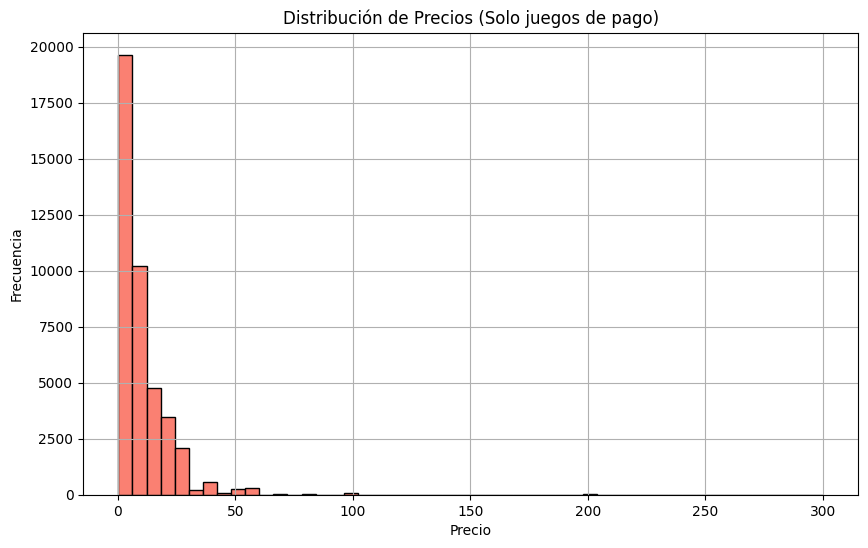

In [8]:
# Chart only for games with a price greater than 0
juegos_pagos = games_df[games_df['price_final'] > 0]
plt.figure(figsize=(10, 6))
juegos_pagos['price_final'].hist(bins=50, color='salmon', edgecolor='black')
plt.title('Distribución de Precios (Solo juegos de pago)')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

In [9]:
# REMOVE DUPLICATE GAMES
cleaned_games_df = games_df.drop_duplicates()

cleaned_games_df.shape


(50872, 13)

In [10]:
# Convertir fecha de lanzamiento a datetime
cleaned_games_df['date_release'] = pd.to_datetime(cleaned_games_df['date_release'])

In [11]:
# Resumen estadístico de precios y reviews
print(cleaned_games_df[['price_final', 'positive_ratio', 'user_reviews']].describe())

        price_final  positive_ratio  user_reviews
count  50872.000000    50872.000000  5.087200e+04
mean       8.620325       77.052033  1.824425e+03
std       11.514164       18.253592  4.007352e+04
min        0.000000        0.000000  1.000000e+01
25%        0.990000       67.000000  1.900000e+01
50%        4.990000       81.000000  4.900000e+01
75%       10.990000       91.000000  2.060000e+02
max      299.990000      100.000000  7.494460e+06


Total de juegos originales: 50872


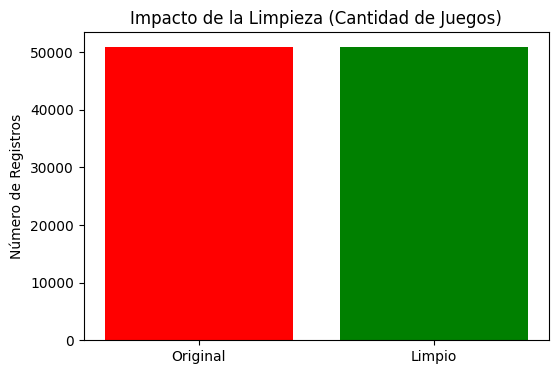

In [12]:
# --- EDA DE LO VIEJO (Original) ---
print(f"Total de juegos originales: {len(games_df)}")

# Un gráfico rápido para ver cuántos duplicados había
plt.figure(figsize=(6, 4))
plt.bar(['Original', 'Limpio'], [len(games_df), len(cleaned_games_df)], color=['red', 'green'])
plt.title('Impacto de la Limpieza (Cantidad de Juegos)')
plt.ylabel('Número de Registros')
plt.show()

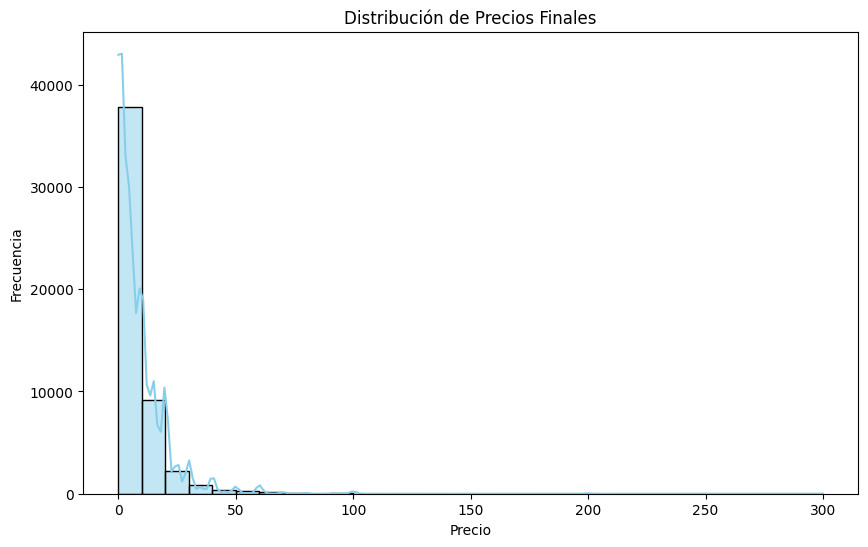

In [13]:
# 1. Distribución de Precios (¿Cuánto cuestan los juegos?)
plt.figure(figsize=(10, 6))
sns.histplot(cleaned_games_df['price_final'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de Precios Finales')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

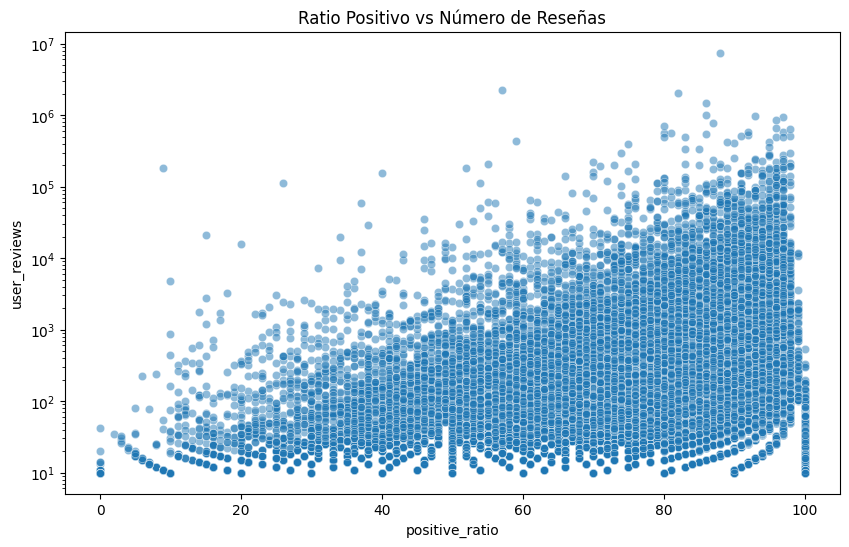

In [14]:
# 2. Relación entre Ratio Positivo y Reseñas de Usuarios
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cleaned_games_df, x='positive_ratio', y='user_reviews', alpha=0.5)
plt.yscale('log') # Usamos escala logarítmica porque hay juegos con muchísimas reviews
plt.title('Ratio Positivo vs Número de Reseñas')
plt.show()

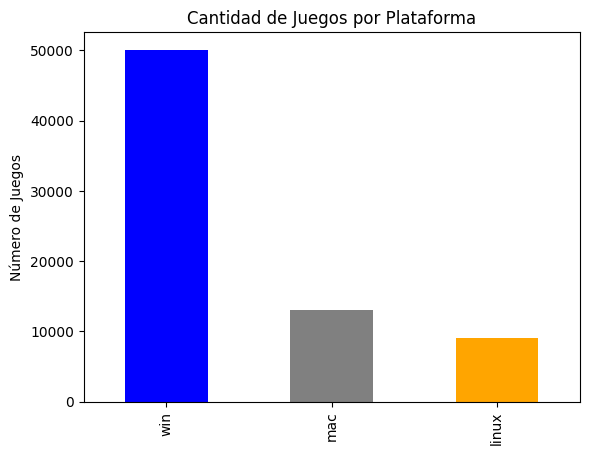

In [15]:
# 3. Conteo de compatibilidad (Windows, Mac, Linux)
platform_counts = cleaned_games_df[['win', 'mac', 'linux']].sum()
platform_counts.plot(kind='bar', color=['blue', 'gray', 'orange'])
plt.title('Cantidad de Juegos por Plataforma')
plt.ylabel('Número de Juegos')
plt.show()

In [16]:
# SAVE CLEANED GAMES
cleaned_games_df.to_csv('../data/processed/games_cleaned.csv', index=False)
print("CLEANED GAMES SAVED.")

CLEANED GAMES SAVED.
